In [1]:
# Config Collab
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append("/content/drive/MyDrive/Obtic/Permanences/Embeddings") # A adapter selon votre chemin

Mounted at /content/drive


# Introduction aux embeddings pour les Humanités Numériques

<img src="https://dhcommons.hypotheses.org/files/2021/04/embedding_vizualization.png" width="600">

### 🎯 Objectifs de la permanence

---

**Comprendre ce que sont les embeddings et appréhender leurs utilisations partiques pour les HN**

1. L'encodage des mots

2. L'encodage des phrases

3. Embeddings et Humanités Numériques

## Introduction

L'idée de base derrière le concept d'**_embeddings_**, c'est de transformer un objet (mot, phrase, image, son...) en un **vecteur sémantique** interprétable pour une machine.

<img src="https://weaviate.io/assets/images/embedding_model-83a51fb9487ceeb03d7af8aeccde3ffb.png" width="700">



Un **vecteur**, c'est une **suite de nombres**. Pendant notre scolarité, on étudie généralement des vecteurs à **2 dimensions**, dans un espace 2D (un plan). Et on les représente dans un **plan** comme des flèches.

<img src="https://www.logamaths.fr/wp-content/uploads/2021/02/Vecteurs-egaux-1024x829.png" width="600">

Eh bien les **embeddings**, c'est pareil, sauf qu'il s'agit de vecteurs pouvant avoir des centaines, voir des **milliers de dimensions** (ou plus encore). L'espace de représentation devient alors inconcevable humainement !

<img src="https://ih1.redbubble.net/image.906441186.2307/raf,360x360,075,t,fafafa:ca443f4786.jpg" width="100">

Un exemple assez intuitif du concept de **vectorisation** est l'**OCR** (_Optical Character Recognition_).

<img src="https://github.com/amandinejvl/ObTIC/blob/main/perm_embeddings/img/9_base.png?raw=true" width="1000">

<img src="https://github.com/amandinejvl/ObTIC/blob/main/perm_embeddings/img/9_pipeline.png?raw=true" width="1000">

Et voilà ! On a réussi à **transformer** une **image** en une **suite de nombres** ! 🥳

En **Humanités Numériques** et en **TAL**, ce type de transformations est fondamental pour de nombreuses applications :

- OCR
- Analyse de corpus visuels
- Comparaison de textes
- Classification de textes et clustering
- Topic modeling
- Recherche sémantique et recommandations
- Traduction automatique
- Transcription automatique
- etc.

L'idée à retenir, c'est la **transformation** d'objets (quels qu'ils soient) en **données interprétables** pour une machine.

## 1. L'encodage des mots

De la même façon qu'on a transformé une image en vecteur, une autre idée forte, particulièrement en **fouille de textes** (_Text Mining_), est la question de la **représentation des mots**.

<img src="https://textmine.sciencesconf.org/data/header/tm.jpg" width="400">

Avant les embeddings, on utilisait différentes stratégies pour **vectoriser** des textes.

#### **Bag of Words (BoW)**

Cette représentation consiste à compter les occurrences de chaque mot dans des textes.

On constitue un **vocabulaire** à partir de tous les mots de l'ensemble des textes. Puis, on représente les textes en fonction du **nombre d'occurrences** de chacun des mots du vocabulaire.

<img src="https://miro.medium.com/v2/resize:fit:828/format:webp/1*sX2Y1Y9Au0hCJzj9qQBV5g.png" width="600">

L'idée derrière la représentation BoW est que deux textes se ressemblent si leurs vecteurs se ressemblent.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd


# Exemple de corpus
corpus = [
    "Le manuscrit médiéval décrit un roi et sa cour.",
    "La reine gouverne le royaume avec sagesse.",
    "Le roman raconte l'histoire d'un jeune paysan.",
    "L'historien étudie le manuscrit ancien avec attention.",
]

# Représentation Bag of Words
bow = CountVectorizer()
X_bow = bow.fit_transform(corpus)
print("Vocabulaire BoW :", bow.get_feature_names_out())


# Matrice BoW
bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=bow.get_feature_names_out(),
    index=[f"doc {i+1}" for i in range(len(corpus))]
)

bow_df

Vocabulaire BoW : ['ancien' 'attention' 'avec' 'cour' 'décrit' 'et' 'gouverne' 'histoire'
 'historien' 'jeune' 'la' 'le' 'manuscrit' 'médiéval' 'paysan' 'raconte'
 'reine' 'roi' 'roman' 'royaume' 'sa' 'sagesse' 'un' 'étudie']


,ancien,attention,avec,cour,décrit,et,gouverne,histoire,historien,jeune,...,paysan,raconte,reine,roi,roman,royaume,sa,sagesse,un,étudie
doc 1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
doc 2,0,0,1,0,0,0,1,0,0,0,...,0,0,1,0,0,1,0,1,0,0
doc 3,0,0,0,0,0,0,0,1,0,1,...,1,1,0,0,1,0,0,0,1,0
doc 4,1,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


La matrice BoW permet de visualiser les vecteurs des textes.

- Les **lignes** correspondent aux **documents**
- Les **colonnes** correspondent aux **mots** du vocabulaire

Chaque intersection correspond ainsi au nombre d'occurrences des mots dans les documents.

#### **TF-IDF**

Cette représentation BoW donne par exemple lieu à la vectorisation **TF-IDF** (_Term Frequency-Inverse Document Frequency_), qui consiste à **pondérer** les comptages d'occurrences des mots pour donner plus de poids aux mots **discriminants**, c'est-à-dire les mots qui sont rares dans le corpus et fréquents dans le document.

**Exemple**

On a un corpus de 1000 textes, dont 24 contiennent le mot "_Liberté_".

On choisit un texte au hasard sans en favoriser aucun.

<img src="https://monecole.fr/wp-content/images/widget/tbi/iconTools/0.png" width="175">

> Serait-il surprenant que le texte contienne le mot "_Liberté_" ?

Oui, car on a assez peu de chances de rencontrer le mot dans le corpus.

→ Surprise 😯

→ Informativité sur le document qu'on vient de piocher

#### **Limites des représentations traditionnelles**

Ces représentations sont très pratiques (et d'ailleurs toujours utilisées) mais elles possèdent néanmoins des limites :

- **Vecteurs de très grande dimension** (autant qu'il y a de mots dans le corpus)
- **Aucune notion sémantique** (ex : "_pauvreté_" et "_misère_" sont aussi éloignés que "_pauvreté_" et "_casserole_")
- **Barrière de la langue** (découle de l'absence de notion sémantique)

Et c'est là que les _embeddings_ interviennent ! 🦸‍♂

#### **Word Embeddings**

Les **_Word Embeddings_** visent à résoudre les limites des méthodes de représentation classiques en capturant du **_sens_**.

<img src="https://web.engr.oregonstate.edu/~huanlian/teaching/ML/2024fall/unit4/figs/word_embeddings_visualization.png" width="700">

Ainsi, les mots partageant des **similarités _sémantiques_** seront plus alors plus **proches** pour la machine !


Le principe est que des modèles **statistiques** apprennent les représentations des mots en étant **entraînés** sur de **grands corpus**.

Les modèles de _Word Embedding_ les plus connus et fréquemment utilisés sont :

- Word2Vec
- GloVe
- _(FastText)_

##### **1. Word2Vec**

En 1957, le linguiste britannique John Rupert Firth dit la chose suivante :

> _"You shall know a word by the company it keeps."_

_(On reconnaît un mot à ses fréquentations)_

<img src="https://citaty-slavnych.sk/media/authors/john-rupert-firth.png" width="125">

Cette idée révolutionnera le TAL une cinquantaine d'années plus tard.

Le sens d'un mot peut-être déduit de ses contextes d'apparition.

**Exemple**

Pour comprendre ce que signifie le mot "_chat_", on peut observer les mots qui l'entourent.

<img src="https://media3.giphy.com/media/v1.Y2lkPTZjMDliOTUyOTBobGVzam5qYTJicndoNnBqcTdjZjFnZ2JydWt2ODlidXI5a3o0bSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/MEsFQDEVsiY4Gxm2LU/giphy.gif" width="150">

> _"Le ___ miaule."_

> _"La souris a peur du_ ____."_

> _"Le ___ a trempé sa patte dans le lait."_

En 2013, **Google** utilise cette hypothèse pour développer un algorithme capable de représenter _sémantiquement_ les mots à partir des mots qui les entourent.

Cet algorithme, c'est **Word2Vec**.

##### **2. GloVe**

L'autre modèle de _Word Embeddings_ connu et fréquemment utilisé est **GloVe**, développé par l'**université de Stanford**, qui lui repose sur le comptage des mots, en exploitant la **matrice de cooccurrence** des mots dans l'ensemble du corpus.

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*h4m0hSKcxGvrG-IMoy2Epg.png" width="600">


Une matrice de cooccurrence est une matrice carrée dont les lignes et les colonnes représentent les mots d'un vocabulaire, et dont les cellules contiennent la **fréquence d'apparition conjointe de paires de mots dans un contexte donné**.

<img src="https://github.com/amandinejvl/ObTIC/blob/main/perm_embeddings/img/matrice_cooccurrence.png?raw=true" width="1000">


Petit exemple avec un modèle GloVe déjà entraîné

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.7 MB/s eta 0:00:00


In [4]:
import gensim.downloader as api

# Charger un modèle déjà entraîné
model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [5]:
# Afficher les 5 mots les plus similaires à king dans le corpus
print("Mots les plus similaires à king :")
print(model.most_similar("king", topn=5))

# Afficher l'analogie roi - homme + femme = ?
print("\nking - man + woman = ?")
print(model.most_similar(positive=["king", "woman"], negative=["man"], topn=1))

Mots les plus similaires à king :
[('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721)]

king - man + woman = ?
[('queen', 0.8523604273796082)]


Les vecteurs de mots produits par ce modèle ont 50 dimensions, ce qui rend difficile leur compréhension.

Toutefois, il existe des algorithmes de **réduction de dimensionnalité** pour représenter ces vecteurs sur un **plan** (en 2D donc), ce qui est quand-même bien pratique quand on veut obtenir une visualisation des mots dans un espace réduit.

Parmi eux, **PCA** (_Principal Component Analysis_), que nous allons tester de ce pas.

<img src="https://media.licdn.com/dms/image/v2/C4D12AQEtW-q4NcDAWg/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1648787394930?e=2147483647&v=beta&t=rTr9aqhvmc-K-Ix1-d1PiOjvji6sOxAX92ehRKjOEsQ" width="700">

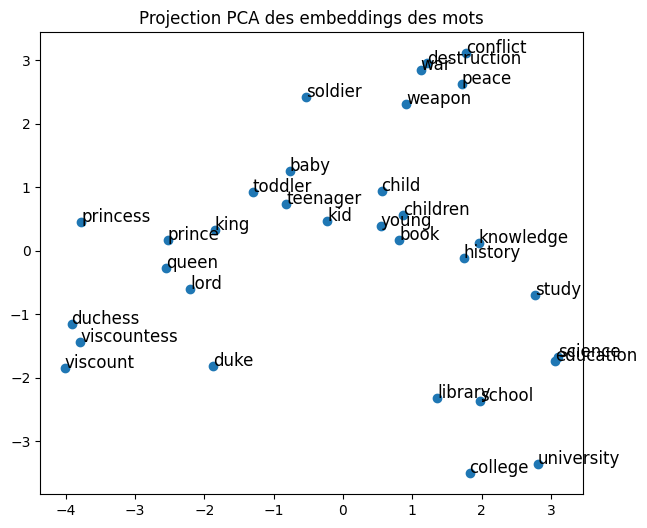

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Mots qu'on va représenter
mots = [
    "king", "queen", "prince", "princess", "lord", "duke", "duchess", "viscount", "viscountess",
    "baby", "child", "children", "kid", "school", "young", "teenager", "toddler",
    "education", "college", "university", "study", "book", "science", "history", "knowledge", "library",
    "war", "weapon", "soldier", "destruction", "conflict", "peace"
]

# Vectoriser les mots avec notre modèle pré-entraîné
vecteurs = np.array([model[m] for m in mots])

# Réduction de dimensionnalité avec PCA
pca = PCA(n_components=2)
vecteurs_2d = pca.fit_transform(vecteurs)

# Tracé du graphe
plt.figure(figsize=(7, 6))
plt.scatter(vecteurs_2d[:, 0], vecteurs_2d[:, 1])
for i, mot in enumerate(mots):
    plt.annotate(mot, vecteurs_2d[i], fontsize=12)
plt.title("Projection PCA des embeddings des mots")
plt.show()


On remarque que les mots qu'on pensait proches sémantiquement se retrouvent dans des zones proches sur le graphique !

On vient de voir qu'il était possible d'utiliser des algorithmes pour capturer le **_sens_** des mots, ou du moins leur **similarité** entre eux.

Et la bonne nouvelle, c'est que cette technique n'est pas réservée qu'aux mots (_Youpi !_ 🥳). On peut également générer des embeddings de **phrases**.

## 2. L'encodage des phrases


Les phrases peuvent elles aussi être représentées par des vecteurs sémantiques, avec des modèles tels que **BERT** ou **GPT**.

Ces _embeddings_, des **_Sentence Embeddings_**, plus larges que ceux des mots offrent de nouvelles applications possibles :

- **Recherche sémantique** (recherche de phrases similaires)
- **Clustering** (regroupement des phrases par signification)
- **Similitude entre phrases** (mesure du degré de similarité entre deux phrases)
- etc.


Petit exemple avec un modèle pré-entraîné

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Modèle multilingue qui fonctionne bien sur le français
model_sentences = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Corpus de phrases
sentences = [
    "Le roi convoque ses conseillers pour discuter de la guerre.",
    "Le souverain réunit sa cour à propos du conflit.",
    "La récolte de blé a été particulièrement mauvaise cette année.",
    "Les paysans se plaignent d'une récolte catastrophique.",
    "L'historienne consulte les archives du XVe siècle.",
]

# Génération des embeddings
embeddings = model_sentences.encode(sentences)

# Dimension des embeddings
print("Dimension des embeddings :", embeddings.shape)

# Matrice de similarité cosinus entre toutes les phrases
similarites = cosine_similarity(embeddings)
print("\nMatrice de similarité :\n", np.round(similarites, 2))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dimension des embeddings : (5, 384)

Matrice de similarité :
 [[ 1.    0.58  0.07  0.18  0.17]
 [ 0.58  1.    0.06  0.08  0.15]
 [ 0.07  0.06  1.    0.68 -0.03]
 [ 0.18  0.08  0.68  1.   -0.03]
 [ 0.17  0.15 -0.03 -0.03  1.  ]]


La **similarité cosinus** est la mesure généralement utilisée pour mesurer la distance entre des embeddings, et plus généralement des vecteurs.

Elle consiste à mesurer le cosinus de l'angle entre deux vecteurs.

- Plus deux **vecteurs sont proches**, plus l'angle est petit et donc plus le **cosinus est élevé**.
- Plus deux **vecteurs sont éloignés**, plus l'angle est grand et donc plus le **cosinus est faible**.



<img src="https://cdn.hashnode.com/res/hashnode/image/upload/v1757481567784/ccd74ce9-d561-47b5-a5e8-c3e77ed36e79.png" width="500">


Petite visualisation

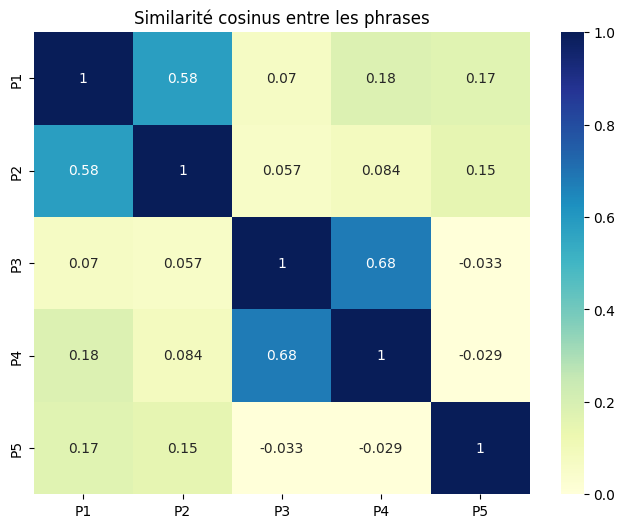

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisation de la matrice de similarité
plt.figure(figsize=(8,6))
sns.heatmap(
    similarites,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    xticklabels=[f"P{i+1}" for i in range(len(sentences))],
    yticklabels=[f"P{i+1}" for i in range(len(sentences))]
)

plt.title("Similarité cosinus entre les phrases")
plt.show()

On peut également faire de la **recherche sémantique** pour trouver les phrases les plus proches _sémantiquement_ d'une phrase donnée.

In [9]:
# Définition de la requête
requete = "Le monarque parle de bataille avec ses ministres."

# Encodage de la requête
embedding_request = model_sentences.encode([requete])

# Calcul des scores de similarité
scores = cosine_similarity(embedding_request, embeddings)[0]

# Extraction de la phrase la plus proche
best_index = scores.argmax()

print(f"Requête : {requete}")
print(f"Phrase la plus proche : {sentences[best_index]}")
print(f"Score de similarité : {scores[best_index]:.3f}")

Requête : Le monarque parle de bataille avec ses ministres.
Phrase la plus proche : Le souverain réunit sa cour à propos du conflit.
Score de similarité : 0.732


**Aucun** mot commun entre la requête et la phrase la plus proche !

Et pourtant les deux ont un **score de similarité** élevé.

## 3. Embeddings et Humanités Numériques

Comme mentionné précédemment, de nombreuses tâches et outils de **TAL** et d'**Humanités Numériques** utilisent des embeddings.

On va ici présenter quelques applications des embeddings en HN.


> **Entraînement d'un modèle de Word Embeddings sur son corpus**
- Topic Modelling : analyse thématique et clustering
- Classification automatique de textes
- Alignement de textes
- Analyse d'images
- Transcription automatique

#### **⚙️ Entraînement d'un modèle de Word Embeddings sur son corpus**

Les modèles de **Word Embeddings**, comme Word2Vec ou GloVe sont généralement entraînés sur de grands corpus pour saisir le sens des mots.

Mais entraîner un modèle de ce type sur son propre corpus présente divers intérêts :

- Capturer la **sémantique propre au corpus** plutôt qu'une sémantique _générale_
- Mener une analyse de l'**évolution temporelle** de l'utilisation d'un mot
- **Comparer** des sous-corpus (auteurs, médias, etc.)
- Détecter des **biais**
- Traiter des **corpus spécialisés**

**Exemple d'application**


_Les Mystères de Paris_, Eugène Sue (1842-1843)

<img src="https://upload.wikimedia.org/wikipedia/commons/6/60/Jules_Ch%C3%A9ret_-_Les_Myst%C3%A8res_de_Paris.jpg" width="300">


**Les Mystères de Paris** est un roman français publié en feuilleton par Eugène Sue dans le Journal des débats entre juin 1842 et octobre 1843. Montrant la misère à Paris et quelques personnages travaillant à rétablir la **justice**, ce roman-fleuve, à mi-chemin entre le **roman social** et le **roman-feuilleton**, inaugure la littérature de masse.

> _Rodolphe, personnage mystérieux au début du roman, s'attelle à rétablir une forme de justice sociale dans le Paris de la première moitié du XIXe siècle. Il croise donc des travailleurs pauvres, aussi bien que des criminels, voulant récompenser les bons et punir les méchants. Les péripéties des héros leur font parcourir Paris et ses environs, décrivant ainsi des lieux types de population : la ferme, l'immeuble du Vieux Paris et les rues._

_(**Source :** [Wikipédia](https://fr.wikipedia.org/wiki/Les_Myst%C3%A8res_de_Paris))_

**1. Chargement des données**

In [10]:
# Chemin vers les données (à adapter selon vos données)
data_dir = "/content/drive/MyDrive/Obtic/Permanences/Embeddings/data/txt"

# Fonction de lecture de fichiers texte
def read_text_file(filepath):
  """Lit un fichier texte"""
  with open(filepath, "r", encoding="utf-8") as f:
    texte = f.read()
  return texte

# Chargement des textes
tome_1 = read_text_file(data_dir + "/Eugene_Sue_Les_mysteres_de_Paris_Tome_1.txt")
tome_2 = read_text_file(data_dir + "/Eugene_Sue_Les_mysteres_de_Paris_Tome_2.txt")
tome_3 = read_text_file(data_dir + "/Eugene_Sue_Les_mysteres_de_Paris_Tome_3.txt")
tome_4 = read_text_file(data_dir + "/Eugene_Sue_Les_mysteres_de_Paris_Tome_4.txt")

# Exemple
print(tome_1[14000:15000])

des le jars14 comme père et mère ! Si tu es grinche15, je ne 
suis pas ton homme. J’ai chouriné16, c’est vrai ; parce que, 
quand le sang me monte aux yeux, j’y vois rouge, et il faut que je 
frappe… mais j’ai payé mes chourinades en allant quinze ans au 
pré17. Mon temps est fini, je ne dois rien aux curieux18, et je n’ai 
jamais grinché19 : demande à la Goualeuse. 
                                       
12 Dieu. 
13 Les prêtres. 
14 Tu parles argot. 
15 Voleur. 
16 Donné des coups de couteau à un homme. 
17 Aux galères. 

 
– C’est vrai, ce n’est pas un voleur, dit celle-ci. 
– Alors, viens boire un verre d’eau d’aff, et tu me 
connaîtras, dit l’inconnu ; allons, sans rancune. 
– C’est honnête de ta part… Tu es mon maître, je le 
reconnais, tu sais rudement jouer des poignets… il y a eu 
surtout la grêle de coups de poing de la fin… Tonnerre ! comme 
ça me pleuvait sur la boule ! je n’ai jamais rien vu de pareil… 
comme c’était festonné ! ça allait comme un marteau de forge. 
C’est 

**2. Nettoyage et normalisation des textes**

In [11]:
# Nettoyage des textes

import re

def clean_text(texte):
  """Nettoie un texte"""

  # Suppression des balises de chapitre
  texte = texte.replace("<NOUVEAU_CHAPITRE>", "")

  # Suppression des notes de bas de page
  texte = re.sub(r"\n\d.+", "", texte)

  # Suppression des sauts de ligne sauf quand la ligne commence par "-"
  texte = re.sub(r"\n(?!–)", "", texte)

  # Suppression des exposants des notes de bas de page
  def delete_nb_in_words(match):
      return match.group(1)
  texte = re.sub(r"([^\W\d_]+)\d+\b", delete_nb_in_words, texte)

  return texte


# Nettoyage
tome_1_clean = clean_text(tome_1)
tome_2_clean = clean_text(tome_2)
tome_3_clean = clean_text(tome_3)
tome_4_clean = clean_text(tome_4)

# Exemple
print(tome_1_clean[12000:15000])

loir se revenger ! 
– Sois tranquille, ma fille, s’il en veut encore, j’ai de quoi le servir. Le brigand entendit ces mots. 
– J’ai la coloquinte en bringues, dit-il à l’inconnu. Pour aujourd’hui j’en ai assez, je n’en mangerai plus ; une autre fois je ne dis pas, si je te retrouve. 
– Est-ce que tu n’es pas content ? est-ce que tu te plains ? s’écria l’inconnu d’un ton menaçant. Est-ce que j’ai macarone ? 
– Non, non, je ne me plains pas : tu es un cadet qui a de l’atout, dit le brigand d’un ton bourru, mais avec cette sorte de considération respectueuse que la force physique impose toujours aux gens de cette espèce. Tu m’as rincé ; et, excepté le Maître d’école, qui mangerait trois Alcides à son déjeuner,                                         personne jusqu’à cette heure ne peut se vanter de me mettre le pied sur la tête. 
– Eh bien ! après ? 
– Après ?… j’ai trouvé mon maître, voilà tout. Tu auras le tien un jour ou l’autre, tôt ou tard… tout le monde trouve le sien… À défaut d’ho

In [12]:
!pip install spacy                           # Installer spaCy
!python3 -m spacy download fr_core_news_sm   # Télécharger un modèle dans la langue du corpus (ici français)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 37.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [13]:
import spacy

# Charger le modèle téléchargé
nlp = spacy.load('fr_core_news_sm')

In [14]:
# Normalisation des textes avec spaCy


# Fonction de normalisation
def normalise_text(text):
  """Normalise un texte et retourne une liste de phrases tokenisées"""
  doc = nlp(text)                                                                   # Traitement du texte avec spaCy
  sentences = []
  for sent in doc.sents:                                                            # Segmentation en phrases
    tokens = []
    for token in sent:
      if not token.is_stop and not token.is_punct and token.lemma_.strip() != '':   # Supression stopwords et ponctuation
        if token.ent_type_:
          tokens.append(token.text.lower())                                         # Conservation des entités nommées
        else:
          tokens.append(token.lemma_.lower())                                       # Lemmatisation des autres tokens
    if tokens:
      sentences.append(tokens)
  return sentences


# Normalisation

print("Normalisation du tome 1...")
tome_1_norm = normalise_text(tome_1_clean)

print("Normalisation du tome 2...")
tome_2_norm = normalise_text(tome_2_clean)

print("Normalisation du tome 3...")
tome_3_norm = normalise_text(tome_3_clean)

print("Normalisation du tome 4...")
tome_4_norm = normalise_text(tome_4_clean)

Normalisation du tome 1...
Normalisation du tome 2...
Normalisation du tome 3...
Normalisation du tome 4...


**3. Entraînement d'un modèle de Word Embeddings**

In [15]:
!pip install glovpy

In [16]:
from glovpy import GloVe

# Entraînement sur notre corpus (concaténation des tomes)
corpus = tome_1_norm + tome_2_norm + tome_3_norm + tome_4_norm
model = GloVe()
model.train(corpus)

Shuffling cooccurrences...
Training model...


**4. Analyse**

In [17]:
# Trouver les mots les plus "similaires" (ceux qui apparaissent dans les mêmes contextes)
model.wv.most_similar("justice")

[('tenter', 0.8076171278953552),
 ('nous', 0.8032773733139038),
 ('connaissance', 0.8032116293907166),
 ('rassurez', 0.7921486496925354),
 ('finir', 0.7877916693687439),
 ('effort', 0.7817248106002808),
 ('pratique', 0.7730007767677307),
 ('mal', 0.7712919116020203),
 ('pardonner', 0.7694391012191772),
 ('premier', 0.76425701379776)]

In [18]:
# Calculer la similarité entre des mots

# Couple 1
mot_1 = "plaisir"
mot_2 = "campagne"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 2
mot_1 = "plaisir"
mot_2 = "paris"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 3
mot_1 = "plaisir"
mot_2 = "table"
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

Similarité entre 'plaisir' et 'campagne' : 0.9100
Similarité entre 'plaisir' et 'paris' : 0.7996
Similarité entre 'plaisir' et 'table' : 0.3490


In [19]:
# Calculer la similarité entre des personnages

# Couple 1
mot_1 = "rodolphe"     # (héros dont le but est de rétablir la justice)
mot_2 = "chouette"     # (vieille femme borgne aux projets diaboliques)
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 2
mot_1 = "rodolphe"     # (héros dont le but est de rétablir la justice)
mot_2 = "goualeuse"    # (jeune femme persécutée par la Chouette, protégée par Rodolphe)
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

# Couple 3
mot_1 = "chouette"     # (héros dont le but est de rétablir la justice)
mot_2 = "goualeuse"    # (jeune femme persécutée par la Chouette, protégée par Rodolphe)
similarity = model.wv.similarity(mot_1, mot_2)
print(f"Similarité entre '{mot_1}' et '{mot_2}' : {similarity:.4f}")

Similarité entre 'rodolphe' et 'chouette' : 0.6435
Similarité entre 'rodolphe' et 'goualeuse' : 0.9033
Similarité entre 'chouette' et 'goualeuse' : 0.7121


In [20]:
!pip install embedding-explorer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 21.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.1/443.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━

In [21]:
from embedding_explorer import show_network_explorer

# Génération d'un réseau sémantique
vocabulary = model.wv.index_to_key
embeddings = model.wv.vectors
show_network_explorer(vocabulary, embeddings=embeddings)

Creating explorer with name: 
Indexing vocabulary for fuzzy search
Indexing done.


<IPython.core.display.Javascript object>

Open in browser:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

<Thread(Thread-8 (_run_silent), stopped 136362388878912)>

L'entraînement d'un modèle de Word Embeddings sur son corpus permet d'obtenir des représentations sémantiques des mots dans ce corpus, et ainsi d'étudier les relations entre les mots dans un contexte donné.

Ce type de travail se prête également bien à l'analyse de **discours médiatiques.**

- Entraînement d'un modèle de Word Embeddings sur son corpus
> **Topic Modelling : analyse thématique et clustering**
- Classification automatique de textes
- Alignement de textes
- Analyse d'images
- Transcription automatique

#### **📑 Topic Modelling : analyse thématique et clustering**

Le modélisation de sujets ou **Topic Modelling** est une méthode qui vise à identifier les **structures thématiques** dans un texte.

Cette technique repose sur la notion de **champs sémantiques**, qui sont des ensembles de mots liés par un domaine ou une thématique.

Par exemple :

- Hôpital : 'chirurgien', 'scalpel', 'infirmière', 'anesthésie'.
- Restaurant : 'serveur', 'menu', 'assiette', 'chef'.
- Maison : 'porte', 'toit', 'cuisine', 'lit'.

(**Source :** _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_preprocessing)_)


Le **Topic Modelling** utilise des algorithmes d'**apprentissage non supervisé** comme le **LDA** (_Latent Dirichlet Allocation_) pour induire des groupes de mots associés à partir de textes.

Les champs sémantiques et le Topic Modelling sont extrêmement utiles pour découvrir les **structures thématiques sous-jacentes** dans de grands corpus documentaires.

(**Source :** _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_preprocessing)_)

Nous allons ici utiliser **BERTopic**, qui utilise des embeddings pour clusteriser des documents.

<img src="https://maartengr.github.io/BERTopic/logo.png" width="200">

**1. Préparation du corpus**

_Chargement : pareil que pour l'entraînement du modèle de Word Embeddings_

Même principe que précédemment, sauf qu'on va découper notre corpus en unités plus larges que les mots : les **chapitres**.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSB1xJLXW5ey4Qn4qWjgV3paRMn5tJK__PqekhH32S5jhNaLCxtn_5sPRII&s=10" width="250">


In [22]:
# Nettoyage des textes et segmentation en chapitres

import re
import pandas as pd


# Fonction de découpage en chapitres
def split_chapitres(texte, numero_tome):
  """Découpe un tome en chapitres"""

  # Segmentation en chapitres
  chapitres = texte.split("<NOUVEAU_CHAPITRE>")
  chapitres = [c for c in chapitres if c.strip() != '']
  titres = [c.split("\n")[2] for c in chapitres]

  # Création du dictionnaire des chapitres avec titres
  data = []
  for i, (chap, titre) in enumerate(zip(chapitres, titres), start=1):
    chap = re.sub(rf"{titre}\n", "", chap)
    chap_clean = clean_text(chap)
    data.append({
        "Tome": numero_tome,
        "Chapitre": i,
        "Titre": titre,
        "Texte": chap_clean
    })

  return data


# Segmentation des tomes en chapitres
chapitres_tome_1 = split_chapitres(tome_1, 1)
chapitres_tome_2 = split_chapitres(tome_2, 2)
chapitres_tome_3 = split_chapitres(tome_3, 3)
chapitres_tome_4 = split_chapitres(tome_4, 4)

# Construction du corpus
all_chapitres = chapitres_tome_1 + chapitres_tome_2 + chapitres_tome_3 + chapitres_tome_4

# Création du DataFrame
chapitres = pd.DataFrame(all_chapitres)

# Exemple
print(chapitres.shape)
chapitres.head()

(140, 4)


,Tome,Chapitre,Titre,Texte
0,1,1,Le tapis-franc,"Un tapis-franc, en argot de vol et de meurtr..."
1,1,2,L’ogresse,Le cabaret du Lapin-Blanc est situé vers le ...
2,1,3,Histoire de la Goualeuse,"\n– Commençons d’abord par le commencement, ..."
3,1,4,Histoire du Chourineur,Le lecteur n’a pas oublié que deux des hôtes...
4,1,5,L’arrestation,"L’homme qui était sorti un moment, après avo..."


In [23]:
# Normalisation des textes avec spaCy

import spacy

# Charger le modèle téléchargé
nlp = spacy.load('fr_core_news_sm')

# Fonction de normalisation par chapitres
def normalise_text_flat(text):
    """Normalise un texte et retourne une liste plate de tokens (pour topic modeling)"""
    doc = nlp(text)
    tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct and token.lemma_.strip() != '':   # Suppression ponctuation + stopwords
            if token.ent_type_:
                tokens.append(token.text.lower())                                     # Conservation entités nommées
            else:
                tokens.append(token.lemma_.lower())                                   # Lemmatisation
    return tokens


def normalise_text_flat(text):
    """Normalise un texte et retourne une liste plate de tokens (pour topic modeling)"""
    doc = nlp(text)
    tokens = []
    for token in doc:
        if not token.is_stop and not token.is_punct and token.lemma_.strip() != '' and not token.ent_type_:   # Suppression ponctuation + stopwords + EN
            tokens.append(token.lemma_.lower())                                                               # Lemmatisation
    return tokens

# Application au corpus
chapitres["Texte_norm"] = chapitres["Texte"].apply(normalise_text_flat)

chapitres.head()

,Tome,Chapitre,Titre,Texte,Texte_norm
0,1,1,Le tapis-franc,"Un tapis-franc, en argot de vol et de meurtr...","[tapis, franc, argot, vol, meurtre, signifier,..."
1,1,2,L’ogresse,Le cabaret du Lapin-Blanc est situé vers le ...,"[cabaret, lapin, blanc, situer, milieu, rue, t..."
2,1,3,Histoire de la Goualeuse,"\n– Commençons d’abord par le commencement, ...","[commencement, oui, parent, reprendre, connai,..."
3,1,4,Histoire du Chourineur,Le lecteur n’a pas oublié que deux des hôtes...,"[lecteur, oublier, hôte, tapis, franc, attenti..."
4,1,5,L’arrestation,"L’homme qui était sorti un moment, après avo...","[homme, sortir, moment, recommander, ogre, bro..."


**2. Encodage des chapitres**

In [24]:
!pip install bertopic
!pip install -U hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.9 MB/s eta 0:00:00


In [25]:
from sentence_transformers import SentenceTransformer

documents = chapitres["Texte"].tolist()
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = embedder.encode(documents, show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

**3. Entraînement de BERTopic**

Cette étape peut être un peu technique donc on va y aller pas à pas.

**Logique générale :**

<img src="https://github.com/amandinejvl/ObTIC/blob/main/perm_embeddings/img/pipeline_bertopic.png?raw=true" width="1000">

In [26]:
# Importation des librairies

from bertopic import BERTopic                                   # Pour entraîner un modèle d'identificaton de thématiques
from sklearn.feature_extraction.text import CountVectorizer     # Pour représenter les topics une fois les clusters formés
from umap import UMAP                                           # Pour la réduction de dimensionnalité pour visualisation
from sklearn.cluster import HDBSCAN                             # Pour le clustering dans l'espace réduit par UMAP

In [27]:
# 1. Réduction de dimensionnalité des embeddings

umap_model = UMAP(
    n_neighbors=15,     # Nombre de voisins considérés pour estimer la structure locale des données (valeur par défaut)
    n_components=2,     # Nombre de dimensions de l'espace réduit (2D)
    min_dist=0.0,       # Distance minimale autorisée entre points dans l'espace réduit (valeur faible favorise le clustering)
    metric='cosine',    # Mesure de distance entre points : similarité cosinus
    random_state=42     # Reproductibilité
)

In [28]:
# 2. Clustering à partir des embeddings réduits

hdbscan_model = HDBSCAN(
    min_cluster_size=5,               # Taille minimale pour qu'un groupe de points soit considéré comme un cluster
    metric='euclidean',               # Distance utilisée dans l'espace réduit par UMAP (standard dans un espace 2D)
    cluster_selection_method='eom'    # Méthode utilisée pour extraire les clusters finaux : Excess of Mass (privilégie clusters stables et de tailles variables)
)

In [29]:
# 3. Caractérisation des topics avec mots-clés

documents_norm = chapitres["Texte_norm"].apply(lambda tokens: " ".join(tokens)).tolist()
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),     # Unigrammes et bigrammes
    min_df=2,               # Ignore les mots/bigrammes qui n'apparaissent que dans un seul chapitre
    max_df=0.9              # Ignore les mots/bigrammes trop fréquents (> 90% des chapitres)
)

In [30]:
# 4. Entraînement du modèle

topic_model = BERTopic(
    embedding_model=embedder,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents_norm, embeddings=embeddings)

2026-07-21 11:55:44,854 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-21 11:56:21,495 - BERTopic - Dimensionality - Completed ✓
2026-07-21 11:56:21,500 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-21 11:56:21,525 - BERTopic - Cluster - Completed ✓
2026-07-21 11:56:21,540 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-21 11:56:23,584 - BERTopic - Representation - Completed ✓


In [31]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15,-1_clerc_vicomte_abbé_maître clerc,"[clerc, vicomte, abbé, maître clerc, laboureur...",[conduire lecteur étude notaire grâce loquacit...
1,0,51,0_abbé_prince_monsieur marquis_belle mère,"[abbé, prince, monsieur marquis, belle mère, c...",[imaginez vous monsieur abbé reprendre adresse...
2,1,34,1_vicomte_ogress_baron_cousin,"[vicomte, ogress, baron, cousin, caveau, vaste...",[bruit venir entendre porte continua tranquill...
3,2,21,2_île_bateau_receleur_voi,"[île, bateau, receleur, voi, demoisell, foular...",[ignorant mauver dessein famille entrer lentem...
4,3,19,3_doyen_singe_huissier_vicomte,"[doyen, singe, huissier, vicomte, chouriner, m...",[détenir parler porter bonnet coton blous gris...


On obtient 4 clusters, correspondant à 4 topics différents (-1 correspond à un cluster bruit)

In [32]:
# Ajout d'une colonne Topic au corpus
chapitres["Topic"] = topics

**4. Analyse**

Une fois qu'on a clusterisé nos chapitres, on peut visualiser la répartition des chapitres par thème.

In [33]:
topic_model.visualize_documents(
    documents_norm,
    embeddings=embeddings,
    hide_annotations=True
)

Comme ce n'est pas hyper clair, voici une version personnalisée à nos données

In [34]:
from plotly import express as px

reduced_embeddings = topic_model.umap_model.embedding_
chapitres["x"] = reduced_embeddings[:, 0]
chapitres["y"] = reduced_embeddings[:, 1]

doc_info = topic_model.get_document_info(documents_norm)
chapitres["Topic_Name"] = doc_info["Name"].values

fig = px.scatter(
    chapitres,
    x="x", y="y",
    color=chapitres["Topic"].astype(str),
    hover_data={
        "Titre": True,
        "Tome": True,
        "Chapitre": True,
        "Topic_Name": True,
        "x": False, "y": False
    },
    labels={
        "color": "Topic"
    },
    title="Chapitres selon leur topic",
    width=900, height=650
)
fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=0.5, color='white')))
fig.show()

On peut, à partir de ce graphique (et de notre connaissance générale de l'histoire), essayer d'attribuer des dynamiques discursives à chaque cluster. Par exemple :

- **topic 0 : Chapitres plutôt positifs 😊**

    _Récompense, La charité, Tu viens bien tard mon ange !, Un ange, Châteaux en Espagne, Consolation, Une ferme modèle_, etc.

- **topic 1 : Chapitres souvent liés explicitement à des lieux 📍**

    _La rue de Chaillot, Un garni, Le jardin d'hiver, L'Île-Adam, Le chemin creux, Le guichet, Le caveau, Le bateau, Le presbytère_, etc.

- **topic 2 : Chapitres plutôt angoissants, en lien avec la prison et/ou des malfrats ☠︎︎**

    _La Force, La Fosse-aux-lions, Saint-Lazare, Le pirate d'eau douce, L'Île du ravageur, Inquiétudes, Dénonciation, La punition_, etc.

- **topic 3 : Chapitres focalisés sur des personnages et/ou leur histoire 👤**

    _Le conteur, François Germain, Pique Vinaigre, Monsieur Pipelet, Murph et Rodolphe, Histoire du Chourineur, Le comte de Saint-Remy, La Chouette_, etc.



Pour des visualisations plus intuitives, et maintenant qu'on a anaylsé un peu les thématiques des clusters, on peut les **renommer**.

In [35]:
custom_labels = {
    -1: "Bruit ❌",
    0: "Positif 😊",
    1: "Lieux 📍",
    2: "Malfrats ☠︎︎",
    3: "Personnages 👤"
}

topic_model.set_topic_labels(custom_labels)

On peut également se demander à quel point les **topics sont proches** les uns des autres

In [36]:
topic_model.visualize_heatmap(custom_labels=True)

Une autre visualisation intéressante dans la cas de l'étude de thématiques dans un roman peut-être l'**évolution des thématiques** en fonction de l'avancement dans l'oeuvre.

In [37]:
timestamps = list(range(len(chapitres)))

topics_over_time = topic_model.topics_over_time(
    documents_norm,
    timestamps,
    nr_bins=20  # regroupe les chapitres en 20 tranches (pour lisibilité)
)

topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10, custom_labels=True)

20it [00:02,  7.95it/s]


On observe par exemple une large prédominance du topic **_"Positif 😊"_** en particulier au milieu du roman.

Le topic **_"Malfrats ☠︎︎"_** a lui surout l'air présent vers la dernière partie de l'oeuvre, et le topic **_"Personnages 👤"_** à la toute fin.

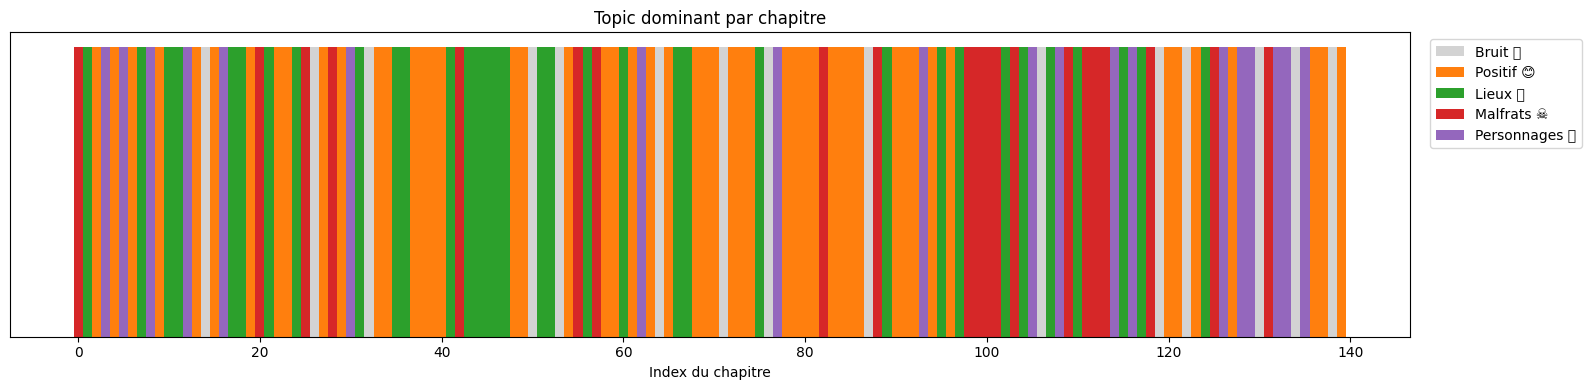

In [38]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(16, 4))

# Couleur par topic (le -1 en gris)
topics_arr = np.array(topics)
unique_topics = sorted(set(topics_arr))
cmap = plt.get_cmap("tab10")
colors = {t: ("lightgray" if t == -1 else cmap(i % 10)) for i, t in enumerate(unique_topics)}

for i, t in enumerate(topics_arr):
    ax.bar(i, 1, width=1, color=colors[t])

ax.set_xlabel("Index du chapitre")
ax.set_yticks([])
ax.set_title("Topic dominant par chapitre")

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[t], label=custom_labels.get(t, f"Topic {t}"))
    for t in unique_topics
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

Mêmes observations mais visualisation différente

On peut aussi observer la **répartition des topics par tome** pour une vision plus globale.

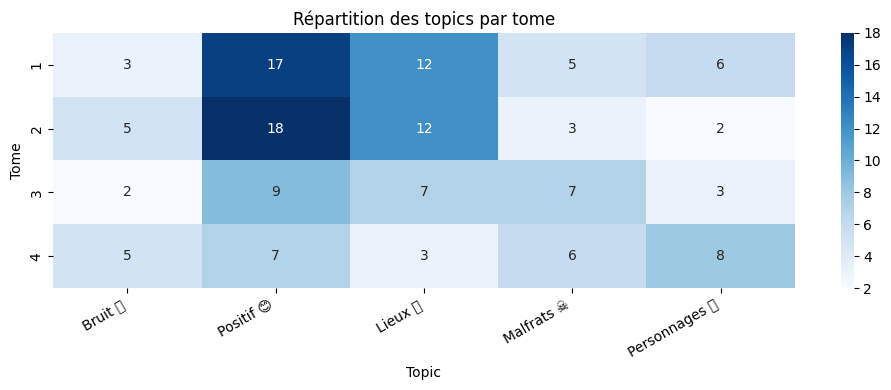

In [39]:
import pandas as pd
import seaborn as sns

pivot = pd.crosstab(chapitres["Tome"], chapitres["Topic"])
pivot = pivot.rename(columns=custom_labels)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Répartition des topics par tome")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

On pourrait encore utiliser tout plein d'autres **visualisations** en fonction de nos **objectifs** de recherche.

On pourrait également refaire les mêmes expériences en conservant les **entités nommées** ou en faisant varier des **paramètres**.

L'idée ici est juste de présenter les possibilités d'exploration génériques.

- Entraînement d'un modèle de Word Embeddings sur son corpus
- Topic Modelling : analyse thématique et clustering
> **Classification automatique de textes**
- Alignement de textes
- Analyse d'images
- Transcription automatique

#### **🏷️ Classification automatique de textes**

Une autre application fréquentes des embeddings est l'entraînement de modèles de **classification** automatique de textes.

Nous allons ici utiliser un corpus de **synopsis de films**, récupérés automatiquement sur Wikipédia à partir de leurs URLs (corpus utilisé pour la [permanence sur spaCy](https://drive.google.com/file/d/1sGZojkBHEceegbSH2D_wfFF-luoJUcAs/view?usp=sharing)). Ce corpus est découpé en 3 catégories, correspondant au **genre** des synopsis de films récupérés :

- **comédie**
- **horreur**
- **documentaire**

Lors de la permanence sur spaCy, nous avions entraîné un modèle de régression logistique à classer automatiquement les synopsis de films, en utilisant une vectorisation **TF-IDF**.

Aujourd'hui, nous allons utiliser des **embeddings**.

**1. Chargement du corpus**

In [40]:
def load_corpus(data_dir: str) -> pd.DataFrame:
    """Fonction pour charger le corpus"""

    # Initialisation d'une liste vide
    corpus = []

    # Parcourir chaque sous-dossier
    for directory in os.listdir(data_dir):
        directory_path = os.path.join(data_dir, directory)
        if os.path.isdir(directory_path):

            # Lire chaque fichier texte
            for file in os.listdir(directory_path):
                if file.endswith(".txt"):
                    filepath = os.path.join(directory_path, file)
                    with open(filepath, "r", encoding="utf-8") as f:
                        texte = f.read()

                    # Récupération du numéro du synopsis pour l'ID
                    name_without_ext = os.path.splitext(file)[0]
                    number = name_without_ext.split("_")[-1]

                    corpus.append({
                        "ID": f"{directory[:3]}{number}",
                        "genre": directory,
                        "texte": texte
                    })

    return pd.DataFrame(corpus)

In [41]:
import os

# Chemin vers les données (adapter à vos données)
data_dir = "/content/drive/MyDrive/Obtic/Permanences/Embeddings/data/synopsis_films"

# Charger et afficher le corpus
corpus = load_corpus(data_dir)
corpus

,ID,genre,texte
0,com25,comedie,Sonia décide de présenter son petit ami Franck...
1,com80,comedie,Monsieur Hulot passe les vacances d'été au bor...
2,com60,comedie,"Glandeur professionnel d'origine canadienne, B..."
3,com17,comedie,"Ariane, une violoniste, accepte la demande en ..."
4,com5,comedie,"Les Tuche, une famille française modeste, voit..."
...,...,...,...
303,hor26,horreur,"Le film commence avec la naissance d’un bébé, ..."
304,hor67,horreur,Alors que la police enquête sur la mort brutal...
305,hor9,horreur,"Henry Frankenstein, un jeune savant, veut crée..."
306,hor28,horreur,"Le jour du réveillon de Noël, quatre mois aprè..."


**2. Préparation du corpus**

In [42]:
from sklearn.model_selection import train_test_split

# Séparer le corpus en ensemble d'entraînement et en ensemble d'évaluation
X_texte = corpus["texte"].tolist()
y = corpus["genre"].values
idx_train, idx_test = train_test_split(
    np.arange(len(corpus)), test_size=0.2, random_state=42, stratify=y
)

y_train, y_test = y[idx_train], y[idx_test]

**3. Encodage avec embeddings**

In [43]:
# Embeddings
vectorizer = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
X = vectorizer.encode(X_texte, show_progress_bar=True)
X_train, X_test = X[idx_train], X[idx_test]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

**4. Entraînement du modèle**

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Entraînement
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

# Performances
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

     comedie       0.80      0.80      0.80        20
documentaire       0.88      0.95      0.91        22
     horreur       0.83      0.75      0.79        20

    accuracy                           0.84        62
   macro avg       0.84      0.83      0.83        62
weighted avg       0.84      0.84      0.84        62



- Entraînement d'un modèle de Word Embeddings sur son corpus
- Topic Modelling : analyse thématique et clustering
- Classification automatique de textes
> **Alignement de textes**
- Analyse d'images
- Transcription automatique

#### **📃 Alignement de textes**

L'alignement de textes est une problématique récurrente en HN, que ce soit pour comparer différentes **versions** d'une même oeuvre, différentes versions **OCR** d'un même ouvrage, des **traductions** d'une oeuvre avec son original, etc.

Toutefois, les approches classiques par similarité textuelle peuvent vite présenter des limites, comme c'est le cas par exemple des alignements de traductions.

Les approches par _embeddings_ permettent d'outrepasser la barrière de la langue, en ne comparant plus leur similarité textuelle mais leur **similarité _sémantique_**.

[Versus](https://versus-obtic.streamlit.app/), une plateforme pour l'**alignement de textes** dévelopée entre autres par Motasem Alrahabi, permet par exemple d'aligner des textes avec une approche sémantique ou combinée (sémantique + lexicale)

<img src="https://github.com/obtic-sorbonne/Versus/blob/main/logo.png?raw=true" width="150">


- Entraînement d'un modèle de Word Embeddings sur son corpus
- Topic Modelling : analyse thématique et clustering
- Classification automatique de textes
- Alignement de textes
> **Analyse d'images**
- Transcription automatique

#### **🖼️ Analyse d'images**

Rappelez-vous, les embeddings ne s'appliquent pas qu'à du texte, on peut également s'en servir pour représenter des **images** !

Présenté par Félix Alié lors de la formation HANDS, [Panoptic](https://panopticorg.github.io/) est un outil de visualisation, d’exploration et d’annotation de grands corpus d’images, développé par le CERES.

<img src="https://ceres.sorbonne-universite.fr/0d727131c157ba2a5175e54a6f2cf93a/panoptic_screenshot.png" width="400">


Cet outil intègre notamment des algorithmes de **groupage d’images par similarité**, ce qui permet d’aider l’usager·e dans le tri et l’exploration. L’outil propose par ailleurs diverses options de filtrage, de recherche et d’annotation, permettant la création, l’analyse et l’exportation de sous-corpus.

_(**Source :** [Site du CERES](https://ceres.sorbonne-universite.fr/Panoptic/))_

- Entraînement d'un modèle de Word Embeddings sur son corpus
- Topic Modelling : analyse thématique et clustering
- Classification automatique de textes
- Alignement de textes
- Analyse d'images
> **Transcription automatique**

#### **📢 Transcription automatique**

De même qu'on peut utiliser les embeddings pour des images, on peut également les utiliser pour du **son**, et plus particulièrement pour la transcription automatique de la parole.

Un des plus connus et utilisés est [Whisper](https://github.com/openai/whisper), un modèle e reconnaissance automatique de la parole développé par **OpenAI**, et qui utilise une architecture encodeur-décodeur, qui globalement correspond à des _embeddings_ audio (représentation de la parole) alignés avec des _embeddings_ textuels (transcription).

<img src="https://media.licdn.com/dms/image/v2/D4D12AQG2X9Y5VrREWA/article-cover_image-shrink_423_752/B4DZVOg73FG4AU-/0/1740779011935?e=2147483647&v=beta&t=j3sxFGngiDOtsgB-wQ9c5EOUHbRcNVv4kRQEOXnNqjs" width="250">



In [45]:
!pip install -U openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 21.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 3.8 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=fea1554db8a8775bff54d002d43f651e3ba3e2d1a934314b46135f3bc068ed08
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [46]:
import whisper

fichier_audio = "/content/drive/MyDrive/Obtic/Permanences/Embeddings/data/audio/La_bise_et_le_soleil.mp3"

model = whisper.load_model("turbo")
result = model.transcribe(fichier_audio)
print(result["text"])

100%|█████████████████████████████████████| 1.51G/1.51G [00:24<00:00, 67.0MiB/s]


 La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort, quand ils ont vu un voyageur qui s'avançait enveloppé dans son manteau. Ils sont tombés d'accord que celui qui arriverait le premier à faire ôter son manteau au voyageur serait regardé comme le plus fort. Alors la bise s'est mise à souffler de toute sa force, mais plus elle soufflait, plus le voyageur serrait son manteau autour de lui. Et à la fin, la bise a renoncé à le lui faire ôter. Alors le soleil a commencé à briller, et au bout d'un moment, le voyageur réchauffé a ôté son manteau. Ainsi la bise a dû reconnaître que le soleil était le plus fort des deux.


## Conclusion

### **🎯 Idée générale derrière les embeddings**

- **Limites des représentations traditionnelles** : pas de capture du sens

- **Embeddings** = représentation sous forme de vecteurs capturant la similarité sémantique des objets

- **Granularité textuelle** : mot, phrase, chapitre, document...

- **Modalité** : texte, image, son...

### **📚 Embeddings et Humanités Numériques**

- Entraînement d'un modèle de **Word Embeddings** sur son corpus
- **Topic Modelling** : analyse thématique et clustering
- **Classification** automatique de textes
- **Alignement** de textes
- Analyse d'**images**
- **Transcription automatique** de la parole

### **💡 Finalement**

Les embeddings ne remplacent pas l'**expertise humaine**, mais constituent un outil pour explorer, structurer et interroger de grands corpus (_distant reading_).

Il est important de garder un **esprit critique** sur ce qu'ils mesurent réellement, et de savoir **choisir l'approche** (granularité, modèle, paramètres, etc.) **la plus adaptée** à sa tâche et à ses données !

## 🔗 Ressources complémentaires

- Bag of Words : [An Introduction to Bag of Words (BoW), 2023](https://medium.com/@vamshiprakash001/an-introduction-to-bag-of-words-bow-c32a65293ccc)

- TF-IDF : [Understanding TF-IDF, 2026](https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/)

- Word2Vec : [Les word embeddings: la géométrie des mots, 2019](https://medium.com/@jessica_51466/les-word-embeddings-la-geom%C3%A9trie-des-mots-4cca8bbc8a2)

- GloVe : [GloVe (Global Vector) — An extension to word2vec embedding technique, 2024](https://medium.com/@abhishekjainindore24/glove-global-vector-an-extension-to-word2vec-embedding-technique-359ce4289908)

- PCA : [Principal Component Analysis (PCA) Made Easy: A Complete Hands-On Guide, 2025](https://medium.com/@sahin.samia/principal-component-analysis-pca-made-easy-a-complete-hands-on-guide-e26a3680c0bc)

- spaCy : [SpaCy Documentation](https://spacy.io/usage/linguistic-features)

- BERTopic : [BERTopic Documentation](https://maartengr.github.io/BERTopic/index.html)

- Lien vers les données du notebook : [Github](https://github.com/amandinejvl/ObTIC/tree/main/perm_embeddings/data)

